# Expression Decoder
Trains an MLP: **(AlphaGenome binned track, scVI cell type embedding) → scalar gene expression**

In [1]:
!pip install -q pandas pyarrow

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [4]:
ORGANS = ['heart', 'lung']
ASSAY  = '10X'
ROOT   = '/content/drive/MyDrive'

TARGET_BINS   = 1024
HIDDEN_DIMS   = [64, 32]
WEIGHT_DECAY  = 1e-4
DROPOUT       = 0.1
LEARNING_RATE = 1e-3
BATCH_SIZE    = 512
EPOCHS        = 30
VAL_SPLIT     = 0.3

## Load Data

In [5]:
# Load each organ's AlphaGenome features and scVI embeddings,
# keeping only cell types that had CL-level AlphaGenome support (not UBERON fallback).
organ_data = {}
for organ in ORGANS:
    ag = np.load(f'{ROOT}/{organ}_{ASSAY}_alphagenome_features.npz', allow_pickle=True)
    cell_type_ids  = ag['cell_type_ids']
    ontology_terms = ag['ontology_terms']

    # cell type has CL support when AlphaGenome used its own CL term, not the organ UBERON fallback
    cl_mask = np.array([ot == ct for ot, ct in zip(ontology_terms, cell_type_ids)])
    if cl_mask.sum() == 0:
        raise ValueError(f'{organ}: no cell types have CL-level AlphaGenome support — check ontology mapping')
    print(f'{organ}: {cl_mask.sum()}/{len(cl_mask)} cell types have CL support — dropping {(~cl_mask).sum()} UBERON fallbacks')

    cell_type_ids = cell_type_ids[cl_mask]

    scvi_df = pd.read_parquet(f'{ROOT}/{organ}_{ASSAY}_cell_type_embeds.parquet')
    scvi_cols = [c for c in scvi_df.columns if c.startswith('scvi_')]

    # Bin 8192 → TARGET_BINS by mean-pooling, then filter to CL cell types
    raw = ag['features'][cl_mask]
    if raw.shape[2] != TARGET_BINS:
        factor = raw.shape[2] // TARGET_BINS
        raw = raw.reshape(*raw.shape[:2], TARGET_BINS, factor).mean(axis=-1).astype(np.float32)

    organ_data[organ] = {
        'features':  raw,
        'labels':    ag['labels'][cl_mask].astype(np.float32),
        'gene_ids':  ag['gene_ids'],
        'scvi':      scvi_df.loc[cell_type_ids, scvi_cols].values.astype(np.float32),
        'n_ct':      int(cl_mask.sum()),
    }
    print(f'  features={raw.shape}')

n_bins   = next(iter(organ_data.values()))['features'].shape[2]
scvi_dim = next(iter(organ_data.values()))['scvi'].shape[1]
print(f'\nn_bins={n_bins}  scvi_dim={scvi_dim}')

heart: 4/15 cell types have CL support — dropping 11 UBERON fallbacks
  features=(4, 10000, 1024)
lung: 6/29 cell types have CL support — dropping 23 UBERON fallbacks
  features=(6, 10000, 1024)

n_bins=1024  scvi_dim=50


## Dataset
Each sample is a **(cell type, gene)** pair. Train/val split on **genes** to avoid leaking genomic context.

In [6]:
# Split on gene_id strings so the same gene is in the same split across all organs
all_gene_ids = sorted(set(gid for d in organ_data.values() for gid in d['gene_ids']))
rng          = np.random.default_rng(42)
shuffled     = rng.permutation(all_gene_ids)
split        = int(len(shuffled) * (1 - VAL_SPLIT))
train_gene_set, val_gene_set = set(shuffled[:split]), set(shuffled[split:])

# Fit sequence scaler on training features across all organs, then normalize each organ
seq_scaler = StandardScaler().fit(np.concatenate([
    d['features'][:, [i for i, g in enumerate(d['gene_ids']) if g in train_gene_set], :].reshape(-1, n_bins)
    for d in organ_data.values()
]))
scvi_scaler = StandardScaler().fit(np.concatenate([d['scvi'] for d in organ_data.values()]))

for d in organ_data.values():
    n_ct, n_genes = d['features'].shape[:2]
    d['features_norm'] = seq_scaler.transform(d['features'].reshape(-1, n_bins)).reshape(n_ct, n_genes, n_bins).astype(np.float32)
    d['scvi_norm']     = scvi_scaler.transform(d['scvi']).astype(np.float32)

class ExpressionDataset(Dataset):
    def __init__(self, gene_set):
        self.samples = [
            (organ, ct, g_idx)
            for organ, d in organ_data.items()
            for g_idx, g_id in enumerate(d['gene_ids']) if g_id in gene_set
            for ct in range(d['n_ct'])
        ]
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        organ, ct, g = self.samples[idx]
        d = organ_data[organ]
        x_seq  = torch.tensor(d['features_norm'][ct, g])   # [n_bins]
        x_scvi = torch.tensor(d['scvi_norm'][ct])          # [scvi_dim]
        y = torch.tensor(d['labels'][ct, g], dtype=torch.float32)
        return x_seq, x_scvi, y

train_loader = DataLoader(ExpressionDataset(train_gene_set), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ExpressionDataset(val_gene_set),   batch_size=BATCH_SIZE)
print(f'Train: {len(train_loader.dataset):,}  Val: {len(val_loader.dataset):,}')

Train: 70,000  Val: 30,000


## Model

In [8]:
class ExpressionDecoder(nn.Module):
    def __init__(self, scvi_dim, hidden_dims, dropout):
        super().__init__()
        # 1D CNN over the binned track: learns local signal patterns regardless of position
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=8, stride=4),   # [B, 32, 31]
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=4, stride=2),  # [B, 64, 14]
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                     # [B, 64, 1]
        )
        dims = [64 + scvi_dim] + hidden_dims
        layers = [l for i in range(len(dims)-1) for l in (nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout))]
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_seq, x_scvi):
        cnn_out = self.cnn(x_seq.unsqueeze(1)).squeeze(-1)  # [B, 64]
        x = torch.cat([cnn_out, x_scvi], dim=1)
        return self.mlp(x).squeeze(-1)

model = ExpressionDecoder(scvi_dim, HIDDEN_DIMS, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model params: {n_params:,}')

Model params: 18,017


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.MSELoss()
train_losses, val_losses, val_rs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for x_seq, x_scvi, y in train_loader:
        x_seq, x_scvi, y = x_seq.to(device), x_scvi.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x_seq, x_scvi), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for xs, xv, y in val_loader:
            val_preds.append(model(xs.to(device), xv.to(device)).cpu().numpy())
            val_labels.append(y.numpy())
    val_preds  = np.concatenate(val_preds)
    val_labels = np.concatenate(val_labels)
    val_loss = float(np.mean((val_preds - val_labels) ** 2))
    val_r    = float(pearsonr(val_preds, val_labels)[0])

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rs.append(val_r)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  train={train_loss:.4f}  val_mse={val_loss:.4f}  val_r={val_r:.4f}')

Epoch   1/30  train=4.0240  val_mse=3.3124  val_r=0.0570
Epoch   5/30  train=2.9567  val_mse=2.9637  val_r=0.3333
Epoch  10/30  train=2.1219  val_mse=2.0476  val_r=0.6220
Epoch  15/30  train=1.9402  val_mse=2.0623  val_r=0.6426
Epoch  20/30  train=1.9078  val_mse=2.2146  val_r=0.6441
Epoch  25/30  train=1.8693  val_mse=1.9463  val_r=0.6454
Epoch  30/30  train=1.8164  val_mse=1.9197  val_r=0.6521


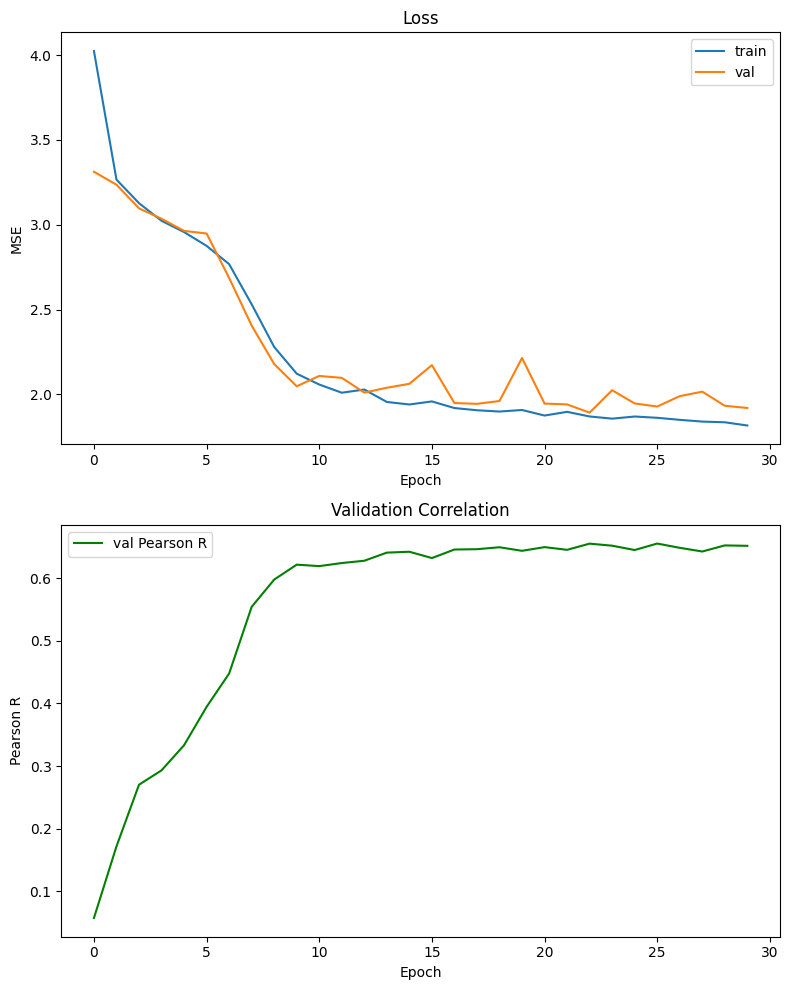

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
ax1.plot(train_losses, label='train'); ax1.plot(val_losses, label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.legend(); ax1.set_title('Loss')
ax2.plot(val_rs, label='val Pearson R', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Pearson R'); ax2.legend(); ax2.set_title('Validation Correlation')
plt.tight_layout(); plt.show()